# Chapter 14: The Globalizer
Train a small **actual PyTorch probabilistic autoregressive network** on
related synthetic continuous demand indices. Shared weights transfer to
entities excluded from training. This Gaussian MLP teaches the global and
distributional ideas; it is not a reproduction of the recurrent DeepAR model.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0, str(ROOT/'companion/src'))
from forecasting_companion.common import begin, save, plt, np
import torch
from torch import nn
import pandas as pd
rng = begin(14)
torch.manual_seed(14)
torch.set_num_threads(1)

## Hold out time AND entity
Thirty-two series teach the network; eight entirely different series are
reserved for evaluation. Each test entity supplies just its latest 14 values
as context. This is short-history transfer, not zero-observation forecasting.
All scales and locations at prediction time use that context alone.

In [2]:
n_train, n_entities, n_days, context = 32, 40, 180, 14
t = np.arange(n_days)
levels = rng.uniform(20, 80, n_entities)
ys = np.stack([level + .12*level*np.sin(2*np.pi*t/7) + rng.normal(0, .05*level, n_days)
               for level in levels])
train_ids, unseen_ids = np.arange(n_train), np.arange(n_train, n_entities)
assert not set(train_ids) & set(unseen_ids)
def features(history, day):
    scale = max(float(np.mean(np.abs(history))), 1e-3)
    return np.r_[history/scale-1, np.sin(2*np.pi*day/7), np.cos(2*np.pi*day/7)], scale
X, Y = [], []
for entity in train_ids:
    for day in range(context, 140):
        x, scale = features(ys[entity, day-context:day], day)
        X.append(x)
        Y.append(ys[entity, day]/scale-1)
X = torch.tensor(np.array(X), dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)
net = nn.Sequential(nn.Linear(context+2, 24), nn.Tanh(), nn.Linear(24, 2))
optimizer = torch.optim.Adam(net.parameters(), lr=.006)
losses = []
for epoch in range(160):
    mu, raw_scale = net(X).unbind(-1)
    sigma = torch.nn.functional.softplus(raw_scale) + .01
    # Gaussian negative log likelihood; constants omitted, hence possibly negative.
    loss = (sigma.log() + .5*((Y-mu)/sigma)**2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))
assert np.isfinite(losses).all() and losses[-1] < losses[0]
print(f'Trained {sum(p.numel() for p in net.parameters())} parameters on {len(Y)} past-only examples.')

Trained 458 parameters on 4032 past-only examples.


## Sample recursively from the fitted distribution
Each path feeds its sampled next value back as a lag, propagating uncertainty
through the horizon. No future observation enters a generated path. The local
baseline repeats the last observed week; it has the same 14-point context.

global_error    2.127
local_error     3.081
covered         0.804
width           6.878


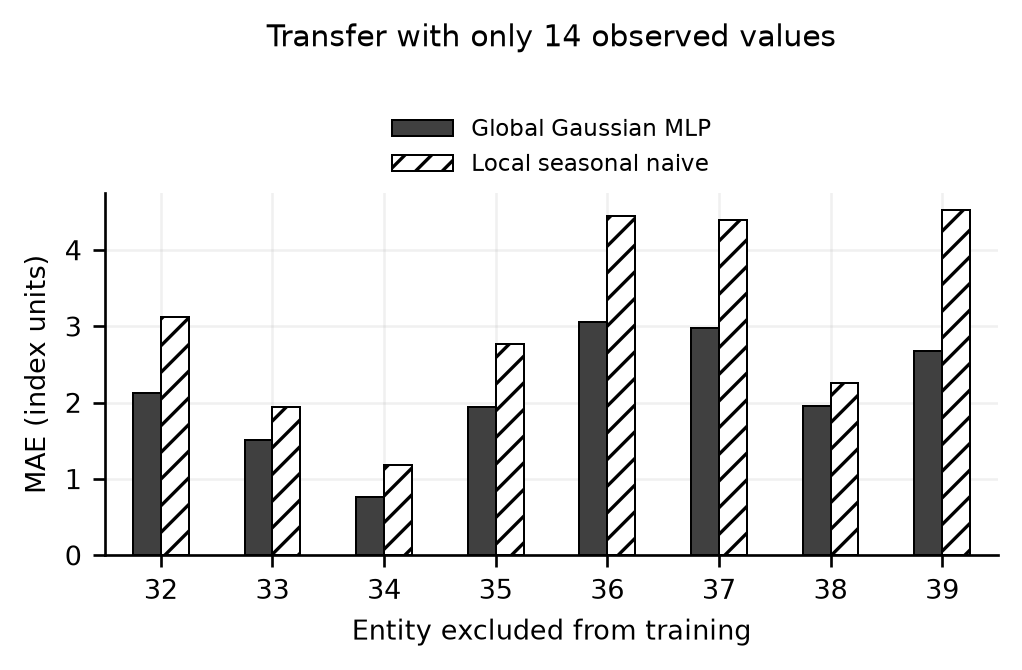

In [3]:
def sample_paths(history, origin, horizon=14, samples=160):
    past = np.tile(np.asarray(history, dtype=float), (samples, 1))
    generated = []
    with torch.inference_mode():
        for day in range(origin, origin+horizon):
            scales = np.maximum(np.abs(past[:, -context:]).mean(axis=1), 1e-3)
            inputs = np.column_stack([past[:, -context:]/scales[:, None]-1,
                                      np.full(samples, np.sin(2*np.pi*day/7)),
                                      np.full(samples, np.cos(2*np.pi*day/7))])
            output = net(torch.tensor(inputs, dtype=torch.float32))
            mu = output[:, 0].numpy()
            sigma = torch.nn.functional.softplus(output[:, 1]).numpy()+.01
            nxt = scales*(1+mu+sigma*rng.normal(size=samples))
            generated.append(nxt)
            past = np.column_stack([past, nxt])
    return np.array(generated).T
records = []
for entity in unseen_ids:
    for origin in [140, 154, 166]:
        history = ys[entity, origin-context:origin]
        paths = sample_paths(history, origin)
        truth = ys[entity, origin:origin+14]
        lo, med, hi = np.quantile(paths, [.1, .5, .9], axis=0)
        local = np.tile(history[-7:], 2)
        for h in range(14):
            records.append(dict(entity=entity, origin=origin, horizon=h+1,
                                global_error=abs(truth[h]-med[h]), local_error=abs(truth[h]-local[h]),
                                covered=lo[h] <= truth[h] <= hi[h], width=hi[h]-lo[h]))
results = pd.DataFrame(records)
print(results[['global_error', 'local_error', 'covered', 'width']].mean().round(3).to_string())
fig, ax = plt.subplots()
by_entity = results.groupby('entity')[['global_error', 'local_error']].mean()
by_entity.rename(columns={'global_error':'Global Gaussian MLP', 'local_error':'Local seasonal naive'}).plot.bar(ax=ax, rot=0)
ax.set(xlabel='Entity excluded from training', ylabel='MAE (index units)', title='Transfer with only 14 observed values')
ax.legend(fontsize=6)
save(14, 1, 'Global transfer to unseen entities',
     'Actual CPU-trained Gaussian autoregressive MLP versus a local seasonal-naive baseline on eight synthetic entities absent from training. Both receive 14 recent observations.',
     'The Catalog and the Cold Start', fig)

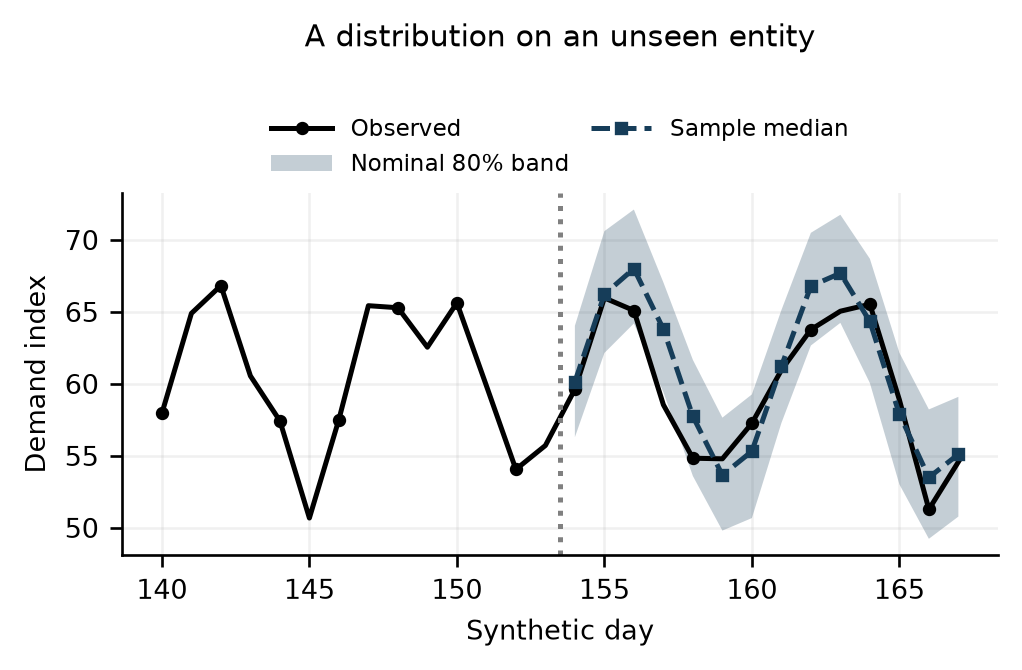

In [4]:
entity, origin = 32,154
paths = sample_paths(ys[entity, origin-context:origin], origin, samples=400)
lo, med, hi = np.quantile(paths, [.1, .5, .9], axis=0)
fig, ax = plt.subplots()
ax.plot(np.arange(origin-context, origin+14), ys[entity, origin-context:origin+14], color='black', label='Observed')
ax.fill_between(np.arange(origin, origin+14), lo, hi, alpha=.25, label='Nominal 80% band')
ax.plot(np.arange(origin, origin+14), med, label='Sample median')
ax.axvline(origin-.5, color='gray', linestyle=':')
ax.set(xlabel='Synthetic day', ylabel='Demand index', title='A distribution on an unseen entity')
ax.legend(fontsize=6)
save(14, 2, 'Autoregressive predictive paths',
     'Synthetic entity 32 was never used for weight updates. Four hundred recursively sampled Gaussian paths yield marginal 10th–90th percentile bands, not simultaneous path coverage.',
     'Section Three: The Probabilistic Imperative', fig)

## Calibration is an empirical question
Compare observed marginal coverage with the nominal 80%. Each horizon has
only 24 entity-origin cases, and overlapping origins create dependence.
A smooth-looking band does not establish good calibration or count-data fit.

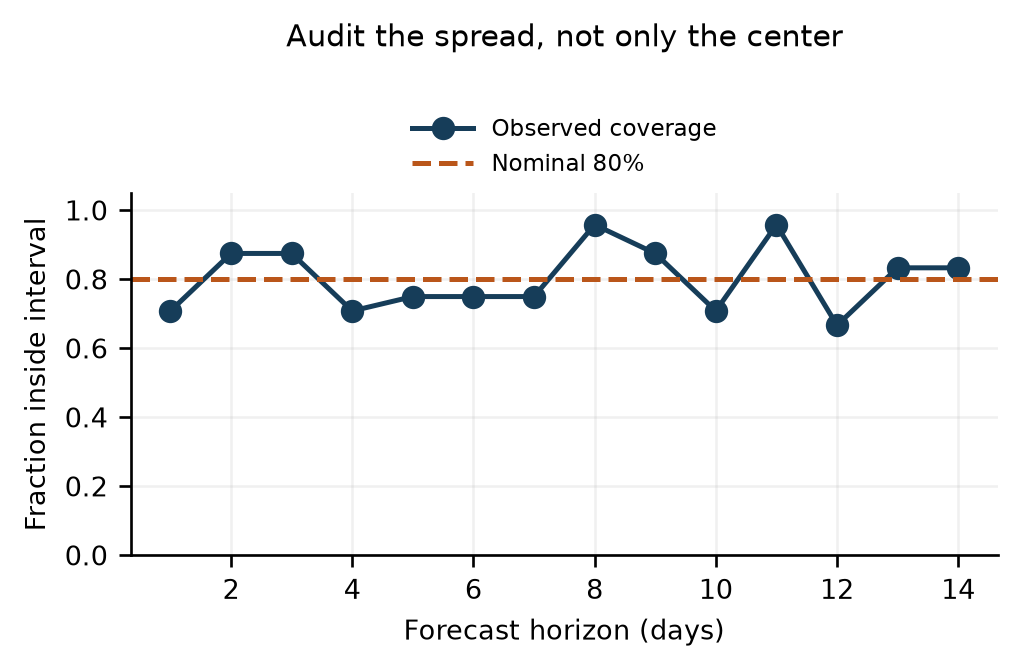

In [5]:
fig, ax = plt.subplots()
coverage = results.groupby('horizon').covered.mean()
ax.plot(coverage.index, coverage.values, marker='o', label='Observed coverage')
ax.axhline(.8, linestyle='--', color='#ba561a', label='Nominal 80%')
ax.set(ylim=(0, 1.05), xlabel='Forecast horizon (days)', ylabel='Fraction inside interval', title='Audit the spread, not only the center')
ax.legend(fontsize=6)
save(14, 3, 'Neural forecast coverage by horizon',
     'Empirical marginal coverage from eight unseen synthetic entities at three origins. Small, dependent samples make this a diagnostic rather than a calibration guarantee.',
     'Section Five: The Distribution and the Decision', fig)

## Limitations and exercise
The shared weekly pattern deliberately favors transfer. The MLP has no
recurrence or learned item embeddings; Gaussian indices are not integer sales.
Negative-binomial output would be more suitable for overdispersed counts.
Training is fixed in advance; evaluation entities never guide hyperparameters.
Exercise: give held-out entities a ten-day rather than weekly cycle. Does
pooling still help? Repeat with multiple seeds and compare interval scores
as well as coverage: arbitrarily wide intervals can cover almost everything.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below connect the controlled figures to a complete applied input/output workflow.

# Chapter 14 workshop: from lesson to decision

## Explain the mechanism

A global model shares parameters across series. A probabilistic autoregressive model predicts a distribution for the next value; recursive sampling carries future uncertainty forward. Cross-entity transfer requires relevant common structure, not simply more rows.

## Work through the arithmetic

If context mean absolute level is 50 and the network predicts normalized mean .1 with normalized SD .2, the original-scale mean is 50×(1+.1)=55 and SD=10. Using a scale computed from future actuals would leak information even if the network weights were frozen.

Treat this hand calculation as a mechanism check. Compare its units and assumptions with the business target before using the executable adapter below.

## Adapt the lesson to reader data

Replace ys and entity splits with aligned observed panels; keep a separate mask for incomplete context. Preserve context-only scaling. Do not let unseen-entity observations contribute training examples; only their pre-origin context can enter prediction.

Keep the controlled example as a reproducible teaching case. Work in a copy when replacing its data; retain raw input, a cleaned table and an explanation of exclusions. Real data need a named source, extraction date, usable-as-of date and units. If an actual is revised later, preserve the vintage available when the forecast would have been issued. Never silently label synthetic generator output as an external dataset.

For this chapter, settle these questions before fitting: Which entities are related and which will be unseen at deployment? How much recent context exists? Is the outcome continuous, count or nonnegative? What horizon and distributional loss matter?

## Interpret the actual lesson outputs

The lesson trains an actual small PyTorch Gaussian MLP, not a recurrent DeepAR implementation. Eight entities are held out from training but provide fourteen observed values. The reported coverage comes from related series and overlapping origins; it is a limited controlled evaluation.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `series_id,timestamp,actual,baseline,lower,median,upper`.
- `summary.json`: inspect `training_entities,held_out_entities,coverage,interval_score,mae,baseline_mae`.

At least four aligned related series are required. The last quarter of sorted entity groups is held out, not a user-configurable split. The actual Gaussian MLP uses 100 recursive paths for nominal 80% bands. It does not implement DeepAR or tune hyperparameters on held-out entities.

The [fixture](../data/examples/ch14.csv) and [config](../configs/ch14.json) match the current interface. Run the `apply` command in the [skill entrypoint](../../forecasting-skills/forecasting-ch14-global-neural/SKILL.md), using a new empty output folder. Any broader methodology in this workshop requires separately recorded evidence or an explicit extension; successful command execution does not imply those steps happened.

## Decide what the evidence supports

Lower training loss does not establish generalization. Gaussian likelihood can assign impossible negative demand. Coverage from many dependent horizon rows is not equivalent to the same count of independent forecast cases. Test entity exclusion and time cutoff explicitly.

With one or a few unrelated series, use a local baseline rather than assuming pooling helps. With no context for a new entity, the demonstrated model is unsupported. If the required neural dependency is missing, report the skipped method honestly.

The applied deliverable must make these items inspectable: Return entity/time split, context and scaling rules, model/training record, sampled forecast quantiles, local-baseline comparison and coverage/width by entity and horizon.

## Three exercises with worked solutions

### Exercise 1

Normalized output mean=-.2, SD=.1, scale=100. Original mean and SD?

**Worked solution.** Mean 80 and SD 10 under the lesson’s centering convention.

### Exercise 2

Test entity history appears in training but future dates do not. Is this unseen-entity evaluation?

**Worked solution.** No. It is temporal generalization for a seen entity; label it accordingly.

### Exercise 3

Why must sampled paths feed back their own values?

**Worked solution.** To propagate uncertainty through autoregressive dependence without importing future actuals.

## Business-reader application

Use this request with the skill:

> Apply chapter 14 to panel.csv with an explicit unseen-entity holdout, compare the actual global Gaussian MLP with local baselines and report uncertainty limitations.

Read the returned result as a decision record. Check that the forecast answers your unit and horizon, that its comparison uses information available at the time, and that any recommendation follows from the stated loss or business objective. Ask which missing measurement would most change the conclusion.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

## Configure and run the applied case

The input file and JSON below are the only entry-point changes needed to try another
case with the same schema. Keep the original examples for comparison. Supply source
and units in the configuration; resolve missing periods rather than silently filling
unknown observations with zeros. These calculations call the same tested functions
as the `run.py apply` command. A failed validation is a reason to inspect the data,
not to replace it with invented observations.

The default input here is a **seeded synthetic schema example**, separate from any
observed-data application below. Read the summary before interpreting its results.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json
import pandas as pd
import json, os
INPUT_PATH = project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists()) / 'companion/data/examples/ch14.csv'
CONFIG_PATH = project_path.parents[2] / 'configs/ch14.json'
# Input paths are explicit and may be replaced with reader-supplied files.
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(14, workshop_input, workshop_config)
print(json.dumps(clean_json(workshop_summary), indent=2))
print(workshop_table.head(12).to_string(index=False))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', CONFIG_PATH.parents[1])) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch14-workshop-results.csv', index=False)
(workshop_output/'ch14-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

{
  "method": "Gaussian autoregressive MLP (not DeepAR)",
  "training_entities": 6,
  "held_out_entities": 2,
  "coverage": 0.7857142857142857,
  "interval_score": 28.43477638163555,
  "mae": 5.588227103675536,
  "baseline_mae": 5.60756575746192,
  "interpretation": "Entity holdout tests transfer of related patterns. 100 recursive paths provide marginal 80% bands. This small Gaussian model is not a count model; hyperparameters are predeclared, not tuned on held-out entities."
}
series_id                 timestamp    actual  baseline     lower    median     upper
   item-6 2021-06-01 00:00:00+00:00 71.466888 73.098761 68.261000 75.932816 84.641152
   item-6 2021-07-01 00:00:00+00:00 73.302026 70.636695 64.901415 72.048874 80.285283
   item-6 2021-08-01 00:00:00+00:00 66.902070 64.333806 57.307248 67.027370 73.445276
   item-6 2021-09-01 00:00:00+00:00 67.967922 60.416572 53.854900 63.122128 69.891818
   item-6 2021-10-01 00:00:00+00:00 65.813630 70.020268 53.418435 60.064888 69.421967
 

483

## Real-data boundary

The bundled case is controlled, not a reconstruction of historical records. No
verified, appropriately licensed domain dataset is supplied for this particular
workflow. Use the input contract to supply your own observations and evidence.
Do not substitute an unrelated public dataset simply to call the example real.
The wider companion includes observed time-series applications in chapters
3–6, 12, 15–16 and 24; their data do not establish this chapter’s domain assumptions.

## Read the result as a decision record

Start with the summary’s **interpretation**, then examine its numerical evidence.
Distinguish what was fitted, what was supplied, and what remains unidentified.
The results table is the calculation; it is not permission to act. Explain which
assumption would most change the answer and what new evidence would test it.
For a live forecast, set an outcome date and keep the original result for scoring.

The exercises and worked solutions above test interpretation, calculation, and
adaptation. Re-run a changed assumption and compare the actual output; do not
reuse numbers from the book when your input or horizon changes.